#### 1. Imports & Dependencies

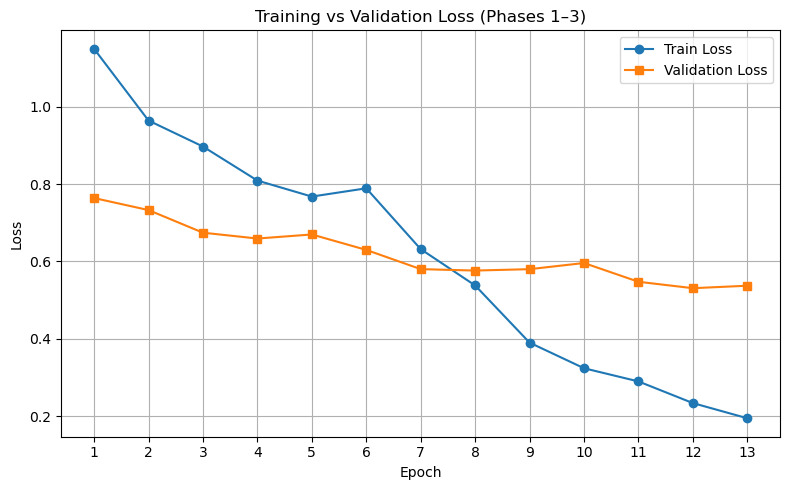

In [1]:
# ——— Actual losses from Phases 1–3 (so far) ———

train_losses = [
    # Phase 1
    1.1496, 0.9641, 0.8969, 0.8089, 0.7675,
    # Phase 2
    0.7889, 0.6316, 0.5377, 0.3898, 0.3236,
    # Phase 3 (to date)
    0.2895, 0.2335, 0.1943
]

val_losses = [
    # Phase 1
    0.7637, 0.7326, 0.6741, 0.6590, 0.6695,
    # Phase 2
    0.6296, 0.5799, 0.5762, 0.5798, 0.5957,
    # Phase 3 (to date)
    0.5472, 0.5306, 0.5370
]

# sanity check
assert len(train_losses) == len(val_losses), \
    f"{len(train_losses)} train vs {len(val_losses)} val points"

# plotting
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses,   marker='s', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Phases 1–3)')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim

#### 2. Utility to load & flatten images

In [ ]:
def load_flattened(folder):
    ds = datasets.ImageFolder(folder, transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]))
    loader = DataLoader(ds, batch_size=len(ds), shuffle=False)
    imgs, labels = next(iter(loader))
    X = imgs.view(len(ds), -1).numpy()  # (N, 3*224*224)
    y = np.array(labels)
    return X, y, ds.classes

#### 2. Model Definition

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # Global pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x



#### 3. Classical baselines: LR & k‑NN

In [ ]:
def run_two_baselines(train_dir, val_dir):
    X_train, y_train, class_names = load_flattened(train_dir)
    X_val,   y_val,   _           = load_flattened(val_dir)

    # Standardize for both models
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_val_s = scaler.transform(X_train), scaler.transform(X_val)

    # 2.1 Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_s, y_train)
    y_pred = lr.predict(X_val_s)
    print("=== Logistic Regression ===")
    print(classification_report(y_val, y_pred, target_names=class_names))

    # 2.2 k‑Nearest Neighbors (k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_val_s)
    print("=== k‑NN (k=5) ===")
    print(classification_report(y_val, y_pred, target_names=class_names))

#### 3. Training & Validation Helpers

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device, class_names):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    return avg_loss, report

#### 4. Main Execution

In [ ]:
def main():
    # 4.1 Configuration
    data_dir = 'data'  # expects 'data/train' and 'data/val'
    batch_size = 32
    learning_rate = 1e-3
    num_epochs = 10
    num_workers = 4

    # 4.2 Device setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 4.3 Data transforms
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    transform_val = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 4.4 Datasets & loaders
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_train)
    val_dataset   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_val)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader    = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)

    # 4.5 Model, loss, optimizer
    num_classes = len(train_dataset.classes)
    model = BaselineCNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 4.6 Training loop
    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_report = validate(model, val_loader, criterion, device, train_dataset.classes)
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val   Loss: {val_loss:.4f}")
        print("  Classification Report:")
        print(val_report)

    # 4.7 Save model
    torch.save(model.state_dict(), 'baseline_skin_cnn.pth')


if __name__ == '__main__':
    main()
